In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import gaussian_kde
from models import CondSM
from utils import f_sm, sample_X, mse_loss_normalized, normalize_over_range


latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print('Libraries loaded')

cuda
Libraries loaded


In [15]:
state_dict = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_vMB_ring_1e7/sm_data_vMB_ring_1e7_baseline_0.pth", weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

input_index_0 = 2
input_index_1 = 4

num_voltages = 7

control_indices = [c_index for c_index in range(num_voltages) if c_index not in (input_index_0,input_index_1)]
#print(control_indices)
# XOR
on_volt = 1.5
gate_inputs = [
    [0.0, 0.0],
    [0.0, on_volt],
    [on_volt, 0.0],
    [on_volt, on_volt]
]

gate = 'XOR'

if gate == 'XOR':
    truth_outputs = [
        0.,
        1.,
        1.,
        0.
    ]

elif gate == 'AND':
    truth_outputs = [
        0.,
        0.,
        0.,
        1.
    ]

elif gate == 'OR':
    truth_outputs = [
        0.,
        1.,
        1.,
        1.
    ]

elif gate == 'NOR':
    truth_outputs = [
        1.,
        0.,
        0.,
        0.
    ]

elif gate == 'NAND':
    truth_outputs = [
        1.,
        1.,
        1.,
        0.
    ]

def plot_gate(model, theta, control_indices, gate_inputs):

    input_tensor = torch.zeros(len(gate_inputs), num_voltages)
    control_voltages = torch.from_numpy(theta).float().expand(len(gate_inputs), -1)
    for j, c_idx in enumerate(control_indices):
        input_tensor[:, c_idx] = control_voltages[:, j]
    
    for k in range(len(gate_inputs)):
        input_tensor[k, input_index_0] = gate_inputs[k][0]
        input_tensor[k, input_index_1] = gate_inputs[k][1]
    input_tensor = input_tensor.to(device)

    model.eval()
    with torch.no_grad():
        y = model(input_tensor).detach().cpu().squeeze().numpy().tolist()

    in_0 = [gate_inputs[0][0], gate_inputs[1][0], gate_inputs[2][0], gate_inputs[3][0]]
    in_1 = [gate_inputs[0][1], gate_inputs[1][1], gate_inputs[2][1], gate_inputs[3][1]]
    
    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True)

    labels = ["$V_0$", "$V_1$", "$I_{\mathrm{out}} \quad [nA]$"]
    
    # time axis: 4 states -> 5 edges
    t = np.arange(len(in_0) + 1)
    
    # helper: nice common style
    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)#, ha="right", va="center")
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        # remove top/right spines
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
    
    # output
    y_out = np.r_[y, y[-1]]
    axes[2].step(t, y_out, where="post", lw=2)
    style_axis(axes[2], labels[2])
    
    # input 0
    y0 = np.r_[in_0, in_0[-1]]
    axes[0].step(t, y0, where="post", lw=2, c='r')
    style_axis(axes[0], labels[0])
    
    # input 1
    y1 = np.r_[in_1, in_1[-1]]
    axes[1].step(t, y1, where="post", lw=2, c='g')
    style_axis(axes[1], labels[1])
    
    # x-ticks at the middle of each interval, labeled by input combination
    centers = np.arange(len(y)) + 0.5
    state_labels = ["00", "01", "10", "11"]
    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(state_labels)
    axes[-1].set_xlabel("Input $V_0, V_1 \quad [V]$")
    
    # small margins so steps aren't glued to edges
    for ax in axes:
        ymin, ymax = ax.get_ylim()
        margin = 0.1 * (ymax - ymin if ymax > ymin else 1.0)
        ax.set_ylim(ymin - margin, ymax + margin)
    
    plt.tight_layout()

print('DONE')

DONE


In [18]:
num_samples = 100_000
c_v_min = -1.5
c_v_max = 1.5
theta_samples = sample_X(num_samples, c_v_min, c_v_max, d=5)

model = model.to(device)
model.eval()
lam = 1e-2
truth_tensor = torch.tensor(truth_outputs, device=device)
scores = []
for n in range(num_samples):
    input_tensor = torch.zeros(len(gate_inputs), num_voltages)
    control_voltages = torch.from_numpy(theta_samples[n]).float().expand(len(gate_inputs), -1)
    for j, c_idx in enumerate(control_indices):
        input_tensor[:, c_idx] = control_voltages[:, j]
    for k in range(len(gate_inputs)):
        input_tensor[k, input_index_0] = gate_inputs[k][0]
        input_tensor[k, input_index_1] = gate_inputs[k][1]
    #print(input_tensor)
    with torch.no_grad():
        input_tensor = input_tensor.to(device)
        y = model(input_tensor).squeeze(1).detach().cpu().numpy().tolist()
        
        I_min = min(y)
        I_max = max(y)

        delta = I_max - I_min
        
        if abs(delta) < 1e-15:
            print("All currents identical, no contrast")

        norm_currents = [(I - I_min) / delta for I in y]
        errors = [abs(g - y) for g, y in zip(truth_outputs, norm_currents)]
        mean_error = sum(errors) / len(errors)

        F0 = 1.0 - mean_error

        denom = max(abs(I_max), abs(I_min), 1e-15)
        bonus = 0.05 * (delta / denom)
        #reg = lam * float(np.sum(np.abs(np.array(theta_samples[n]))))
        reg = lam * float(np.dot(np.array(theta_samples[n]), np.array(theta_samples[n])))
        
        fitness = F0 + bonus + reg
        scores.append(fitness)
        """y = np.array(y)
        low_mask = np.array(truth_outputs) == 0
        high_mask = np.array(truth_outputs) == 1

        low_curr = y[low_mask]
        high_curr = y[high_mask]
        margin = high_curr.min() - low_curr.max()
        Ion = high_curr.mean()
        Ioff = low_curr.mean()
        ratio = Ion / (Ioff + 1e-12)

        score = np.maximum(margin, 0.0) * ratio

        scores.append(score.item())"""

print('Done')

Done


57479
0.08785241065585064
0.9961231338660985
True Is: [array([4.09910052e-20]), array([4.06925745e-20]), array([4.13797243e-20]), array([3.91228834e-20])]
Best theta: [-0.19557869 -0.78862113 -1.11523697  0.99844417 -1.44972628]


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

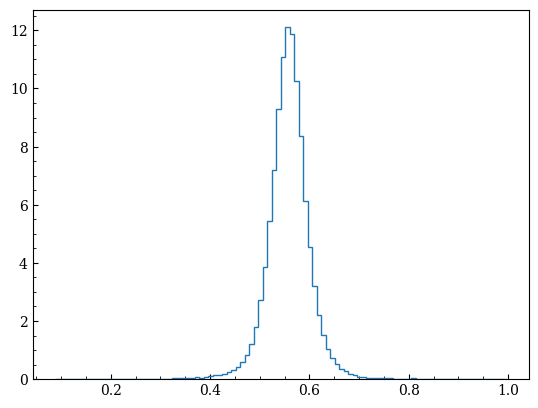

In [16]:
min_score = min(scores)
max_score = max(scores)
max_index = scores.index(max_score)
print(max_index)
print(min_score)
print(max_score)
bins = 100
fig, ax = plt.subplots()
ax.minorticks_on()
ax.tick_params(which='both', direction='in')
ax.hist(scores, bins=bins, density=True, histtype='step')

C = 1.602e-19
I_00 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/gate=XOR_0.0_0.0.npz')['current']
I_01 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/gate=XOR_0.0_1.0.npz')['current'] 
I_10 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/gate=XOR_1.0_0.0.npz')['current'] 
I_11 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/gate=XOR_1.0_1.0.npz')['current']

true_Is = [I_00, I_01, I_10, I_11]
print('True Is:', true_Is)
      
best_theta = np.array([-0.19557869, -0.78862113, -1.11523697, 0.99844417, -1.44972628])#theta_samples[max_index]
print('Best theta:', best_theta)

plot_gate(model, best_theta, control_indices, gate_inputs)
plt.scatter(np.arange(4), true_Is)
plt.show()

Step     0 | fitness = 0.534414 | theta = [-0.9195834   0.30742604 -1.3073255   1.0945253   1.2345507 ]
Step  1000 | fitness = 0.606755 | theta = [-0.6966906  -0.01529718 -0.9632057   1.5         0.75930357]
Step  2000 | fitness = 0.606637 | theta = [-0.69635564 -0.01382994 -0.96185225  1.5         0.7554647 ]
Step  3000 | fitness = 0.606692 | theta = [-0.69596237 -0.00388855 -0.96208775  1.5         0.75144994]
Step  4000 | fitness = 0.606707 | theta = [-0.6972667  -0.00747831 -0.9626726   1.5         0.75818014]
Step  5000 | fitness = 0.606728 | theta = [-0.6965591  -0.01478818 -0.9636435   1.5         0.75682884]
Step  6000 | fitness = 0.606729 | theta = [-0.6971329  -0.01594194 -0.9639607   1.5         0.7584377 ]
Step  7000 | fitness = 0.606545 | theta = [-0.6977928  -0.01074487 -0.9617829   1.5         0.75897336]
Step  8000 | fitness = 0.606789 | theta = [-0.6945246  -0.01561258 -0.9640857   1.5         0.75931764]
Step  9000 | fitness = 0.606741 | theta = [-0.6962472  -0.015040

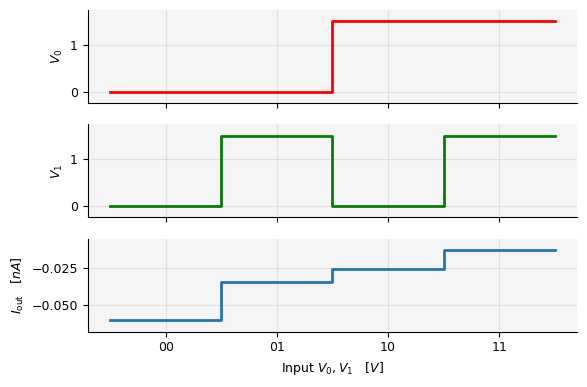

In [6]:
num_iterations = 1000

def compute_fitness(theta_param: torch.Tensor) -> torch.Tensor:
    """
    theta_param: shape (5,) – one voltage for each control index
    returns: scalar fitness (to be maximized)
    """
    # Build input tensor for the 4 gate inputs
    input_tensor = torch.zeros(len(gate_inputs), num_voltages, device=device)

    # Set control voltages
    for j, c_idx in enumerate(control_indices):
        input_tensor[:, c_idx] = theta_param[j]

    # Set logic inputs
    for k, (v0, v1) in enumerate(gate_inputs):
        input_tensor[k, input_index_0] = v0
        input_tensor[k, input_index_1] = v1

    # Forward pass
    y = model(input_tensor).squeeze(1)  # shape (4,)

    # Your normalisation and fitness calculation in torch
    I_min = y.min()
    I_max = y.max()
    delta = I_max - I_min

    # Avoid division by 0 if all currents are identical
    eps = 1e-15
    delta_safe = torch.where(delta.abs() < eps,
                             torch.full_like(delta, eps),
                             delta)

    norm_currents = (y - I_min) / delta_safe   # shape (4,)

    # Mean absolute error w.r.t truth table
    errors = (truth_tensor - norm_currents).abs()
    mean_error = errors.mean()

    F0 = 1.0 - mean_error

    # Bonus term
    denom = torch.maximum(
        torch.maximum(I_max.abs(), I_min.abs()),
        torch.tensor(eps, device=device)
    )
    bonus = 0.05 * (delta / denom)

    fitness = F0 + bonus
    return fitness

for param in model.parameters():
    param.requires_grad_(False)
model.eval()
model = model.to(device)

c_v_min = -1.5
c_v_max = 1.5
theta_vector = nn.Parameter(
    torch.empty(5, device=device).uniform_(c_v_min, c_v_max)
)
optimizer = torch.optim.Adam([theta_vector], lr=1e-2)

num_steps = 10_000  # choose how long you want to optimize

truth_tensor = torch.tensor(truth_outputs, device=device, dtype=torch.float32)
for step in range(num_steps):
    optimizer.zero_grad()

    fitness = compute_fitness(theta_vector)
    loss = -fitness  # maximize fitness

    loss.backward()
    optimizer.step()

    # Optional: clamp theta to a valid voltage range, e.g. [0, 1]
    with torch.no_grad():
        theta_vector.clamp_(c_v_min, c_v_max)

    if step % 1000 == 0:
        print(f"Step {step:5d} | fitness = {fitness.item():.6f} | theta = {theta_vector.detach().cpu().numpy()}")

best_theta = theta_vector.detach().cpu().numpy()
print(best_theta)

plot_gate(model, best_theta, control_indices, gate_inputs)